In [1]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np
import os

In [2]:
root = "/home/acomajuncosa/Documents_GPU/mtb-targeted-protein-degradation/notebooks"
PATH_TO_SUMMARY = os.path.join(root, "..", "processed", "unidock_REAL_docking", "inference_10B", 'shared_compounds')

In [3]:
# First example

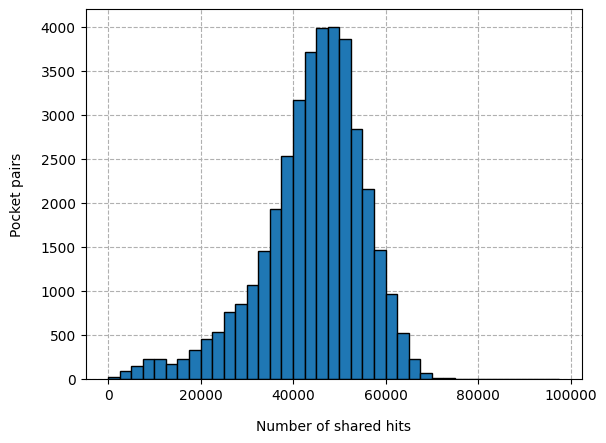

In [4]:
df = pd.read_csv(os.path.join(PATH_TO_SUMMARY, "Enamine_REAL_LeadLike_000.csv"))
SHARED_HITS_SAME_POCKET = list(np.array(df[df['set'] == 'SAME_POCKET']['indices'].tolist()[0].split(";"), dtype=np.int32))
SHARED_HITS_SAME_PROTEIN = list(np.array(df[df['set'] == 'SAME_PROTEIN']['indices'].tolist()[0].split(";"), dtype=np.int32))
SHARED_HITS_DIFF_PROTEIN = list(np.array(df[df['set'] == 'DIFF_PROTEIN']['indices'].tolist()[0].split(";"), dtype=np.int32))

bins = [i for i in range(0, 100_000, 2_500)]
h = SHARED_HITS_SAME_POCKET + SHARED_HITS_SAME_PROTEIN + SHARED_HITS_DIFF_PROTEIN

plt.hist(h, bins=bins, edgecolor='k', linewidth=1, zorder=2, density=False)
plt.grid(linestyle='--', zorder=-2)
plt.ylabel("Pocket pairs", labelpad=12)
plt.xlabel("Number of shared hits", labelpad=12)
plt.show()

In [5]:
# from collections import Counter
# counting_cpds = Counter([ind for pocket in sorted(TOPs) for ind in TOPs[pocket]])
# print(len([i for i in counting_cpds if counting_cpds[i] > 0]))
# print(len([i for i in counting_cpds if counting_cpds[i] > 200]))

In [6]:
SHARED_HITS_DIFF_PROTEIN = []
SHARED_HITS_SAME_PROTEIN = []
SHARED_HITS_SAME_POCKET = []

for chunk in tqdm(sorted(os.listdir(PATH_TO_SUMMARY))):

    # Read results
    df = pd.read_csv(os.path.join(PATH_TO_SUMMARY, chunk))
    a = list(map(int, df[df['set'] == 'SAME_POCKET']['indices'].tolist()[0].split(";")))
    b = list(map(int, df[df['set'] == 'SAME_PROTEIN']['indices'].tolist()[0].split(";")))
    c = list(map(int, df[df['set'] == 'DIFF_PROTEIN']['indices'].tolist()[0].split(";")))

    # Store results
    SHARED_HITS_SAME_POCKET.extend(a)
    SHARED_HITS_SAME_PROTEIN.extend(b)
    SHARED_HITS_DIFF_PROTEIN.extend(c)

100%|██████████| 994/994 [04:01<00:00,  4.11it/s]


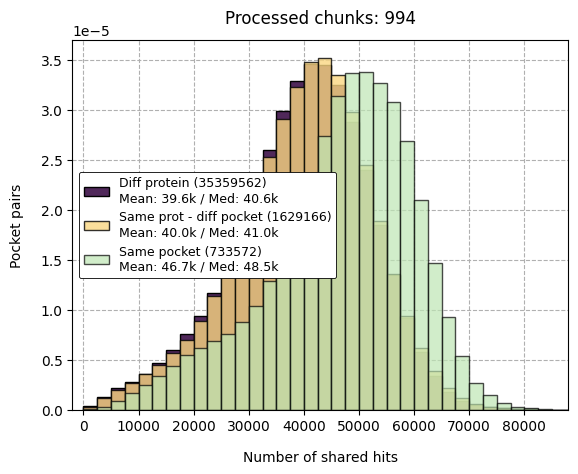

In [7]:
bins = [i for i in range(0, 100_000, 2_500)]

def fmt_k(x):
    x = float(x)
    return f"{x/1000:.1f}k" if abs(x) >= 1000 else f"{x:.1f}"

label1 = f"Diff protein ({len(SHARED_HITS_DIFF_PROTEIN)})\nMean: {fmt_k(np.mean(SHARED_HITS_DIFF_PROTEIN))} / Med: {fmt_k(np.median(SHARED_HITS_DIFF_PROTEIN))}"
label2 = f"Same prot - diff pocket ({len(SHARED_HITS_SAME_PROTEIN)})\nMean: {fmt_k(np.mean(SHARED_HITS_SAME_PROTEIN))} / Med: {fmt_k(np.median(SHARED_HITS_SAME_PROTEIN))}"
label3 = f"Same pocket ({len(SHARED_HITS_SAME_POCKET)})\nMean: {fmt_k(np.mean(SHARED_HITS_SAME_POCKET))} / Med: {fmt_k(np.median(SHARED_HITS_SAME_POCKET))}"

plt.title(f"Processed chunks: {int(len(SHARED_HITS_SAME_POCKET) / 738)}", pad=12)
plt.hist(SHARED_HITS_DIFF_PROTEIN, bins=bins, edgecolor='k', linewidth=1, color="#50285A", label=label1, zorder=2, density=True)
plt.hist(SHARED_HITS_SAME_PROTEIN, bins=bins, edgecolor='k', linewidth=1, color="#FAD782", label=label2, zorder=2, density=True, alpha=0.8)
plt.hist(SHARED_HITS_SAME_POCKET, bins=bins, edgecolor='k', linewidth=1, color="#BEE6B4", label=label3, zorder=2, density=True, alpha=0.7)

l = plt.legend(framealpha=1, edgecolor='k', prop={'size': 9}, loc='center left')
l.get_frame().set_linewidth(0.6)
plt.xlim([-2000, 88000])
plt.grid(linestyle='--', zorder=-2)
plt.ylabel("Pocket pairs", labelpad=12)
plt.xlabel("Number of shared hits", labelpad=12)
plt.show()